# Pokemon Dataset — Exploratory Analysis

Exploration of Pokemon data pulled from PokeAPI (see `pokemon-api-fetch`): base stats,
types, moves, and game-version availability for 1,351 Pokemon.

Sections:
1. Load & inspect data
2. Derived fields (total stats, stat ratios, category flags)
3. Stat distributions & correlations
4. Type analysis
5. Legendary / mythical / baby comparison
6. Moves analysis
7. Game-version availability
8. Next steps


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
%matplotlib inline


## 2. Load data

Four CSVs, all keyed on Pokemon id/name:
- `pokemon.csv` — one row per Pokemon (base stats, height/weight, baby/mythical/legendary flags)
- `types.csv` — long format, one row per (pokemon, type) — most Pokemon have 1-2 rows
- `moves.csv` — long format, one row per (pokemon, move) it can learn
- `regions.csv` — long format, one row per (pokemon, game version) it appears in. Despite the
  filename (inherited from the fetch script), the values are game *versions* (e.g. `red`,
  `heartgold`, `sword`), not geographic regions.


In [2]:
DATA_DIR = "data"

pokemon = pd.read_csv(f"{DATA_DIR}/pokemon.csv")
types = pd.read_csv(f"{DATA_DIR}/types.csv")
moves = pd.read_csv(f"{DATA_DIR}/moves.csv")
versions = pd.read_csv(f"{DATA_DIR}/regions.csv").rename(columns={
    "region_id": "version_id", "region_name": "version_name"
})

print("pokemon:", pokemon.shape)
print("types:  ", types.shape)
print("moves:  ", moves.shape)
print("versions:", versions.shape)
pokemon.head()


pokemon: (1351, 14)
types:   (2116, 4)
moves:   (99509, 4)
versions: (9058, 4)


,id,name,base_experience,height,weight,hp,attack,defense,special-attack,special-defense,speed,is_baby,is_mythical,is_legendary
0,1,bulbasaur,64.0,7,69,45,49,49,65,65,45,False,False,False
1,2,ivysaur,142.0,10,130,60,62,63,80,80,60,False,False,False
2,3,venusaur,236.0,20,1000,80,82,83,100,100,80,False,False,False
3,4,charmander,62.0,6,85,39,52,43,60,50,65,False,False,False
4,5,charmeleon,142.0,11,190,58,64,58,80,65,80,False,False,False


## 3. Basic inspection

In [3]:
pokemon.info()


<class 'pandas.DataFrame'>
RangeIndex: 1351 entries, 0 to 1350
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1351 non-null   int64  
 1   name             1351 non-null   str    
 2   base_experience  1302 non-null   float64
 3   height           1351 non-null   int64  
 4   weight           1351 non-null   int64  
 5   hp               1351 non-null   int64  
 6   attack           1351 non-null   int64  
 7   defense          1351 non-null   int64  
 8   special-attack   1351 non-null   int64  
 9   special-defense  1351 non-null   int64  
 10  speed            1351 non-null   int64  
 11  is_baby          1351 non-null   bool   
 12  is_mythical      1351 non-null   bool   
 13  is_legendary     1351 non-null   bool   
dtypes: bool(3), float64(1), int64(9), str(1)
memory usage: 120.2 KB


In [4]:
# Missing values per column
pokemon.isna().mean().sort_values(ascending=False).to_frame("pct_missing")


,pct_missing
base_experience,0.036269
id,0.000000
name,0.000000
height,0.000000
weight,0.000000
hp,0.000000
attack,0.000000
defense,0.000000
special-attack,0.000000
special-defense,0.000000


In [5]:
# base_experience is the only column with gaps -- who's missing it?
pokemon.loc[pokemon["base_experience"].isna(), ["id", "name"]]


,id,name
1302,10278,clefable-mega
1303,10279,victreebel-mega
1304,10280,starmie-mega
1305,10281,dragonite-mega
1306,10282,meganium-mega
1307,10283,feraligatr-mega
1308,10284,skarmory-mega
1309,10285,froslass-mega
1310,10286,emboar-mega
1311,10287,excadrill-mega


In [6]:
pokemon.describe()


,id,base_experience,height,weight,hp,attack,defense,special-attack,special-defense,speed
count,1351.000000,1302.000000,1351.000000,1351.000000,1351.000000,1351.000000,1351.000000,1351.000000,1351.000000,1351.000000
mean,2841.692080,161.943932,20.443375,991.059956,71.673575,82.757957,76.193930,75.418209,74.115470,72.000000
std,4139.019112,82.532554,53.238467,1953.115812,26.827529,32.351906,30.712902,34.026272,27.800826,30.642043
min,1.000000,36.000000,1.000000,0.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000
25%,338.500000,71.000000,6.000000,94.500000,55.000000,60.000000,55.000000,50.000000,54.000000,49.000000
50%,676.000000,165.000000,11.000000,326.000000,70.000000,80.000000,70.000000,69.000000,70.000000,70.000000
75%,1013.500000,222.500000,17.000000,853.500000,85.000000,102.500000,95.000000,97.000000,90.000000,95.000000
max,10326.000000,608.000000,1000.000000,10000.000000,255.000000,190.000000,250.000000,216.000000,250.000000,200.000000


In [7]:
# Cardinality sanity checks
for col in ["id", "name"]:
    print(f"{col:10s} -> {pokemon[col].nunique():,} unique / {len(pokemon):,} rows")

print("\nDistinct types:  ", types["type_name"].nunique())
print("Distinct moves:  ", moves["move_name"].nunique())
print("Distinct versions:", versions["version_name"].nunique())


id         -> 1,351 unique / 1,351 rows
name       -> 1,351 unique / 1,351 rows

Distinct types:   18
Distinct moves:   833
Distinct versions: 41


## 4. Derived fields

- `total_stats` — sum of the six base stats (a common single-number "how strong" proxy)
- `bulk` — height * weight, a rough size proxy
- `category` — baby / mythical / legendary / normal, collapsed into one label


In [8]:
stat_cols = ["hp", "attack", "defense", "special-attack", "special-defense", "speed"]

pokemon["total_stats"] = pokemon[stat_cols].sum(axis=1)
pokemon["bulk"] = pokemon["height"] * pokemon["weight"]

def categorize(row):
    if row["is_legendary"]:
        return "legendary"
    if row["is_mythical"]:
        return "mythical"
    if row["is_baby"]:
        return "baby"
    return "normal"

pokemon["category"] = pokemon.apply(categorize, axis=1)
pokemon["category"].value_counts()


category
normal       1174
legendary     120
mythical       38
baby           19
Name: count, dtype: int64

## 5. Stat distributions & correlations

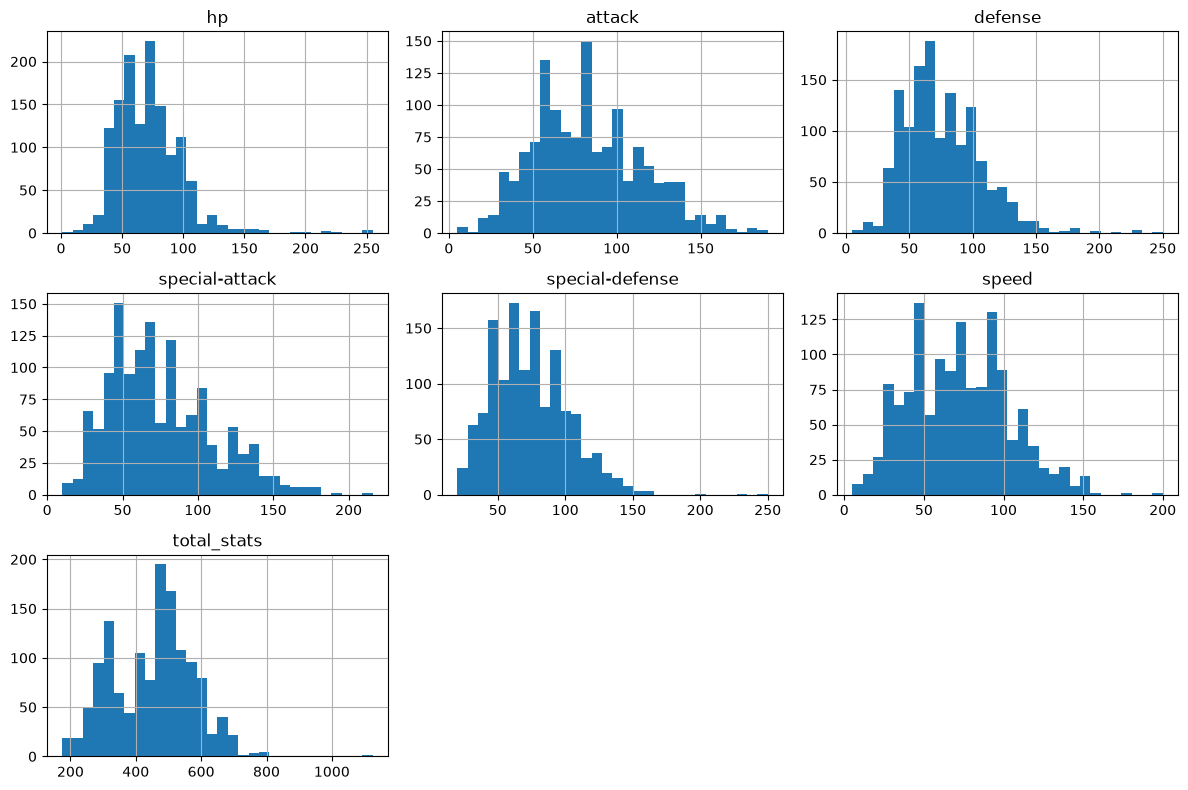

In [9]:
pokemon[stat_cols + ["total_stats"]].hist(figsize=(12, 8), bins=30)
plt.tight_layout()


In [10]:
corr = pokemon[stat_cols + ["total_stats", "height", "weight"]].corr()
corr


,hp,attack,defense,special-attack,special-defense,speed,total_stats,height,weight
hp,1.000000,0.461242,0.342287,0.355107,0.386716,0.158947,0.653022,0.280982,0.364706
attack,0.461242,1.000000,0.481173,0.310366,0.278017,0.357429,0.724717,0.174121,0.322204
defense,0.342287,0.481173,1.000000,0.239938,0.544878,0.013949,0.646779,0.197031,0.337383
special-attack,0.355107,0.310366,0.239938,1.000000,0.521251,0.424388,0.722367,0.148362,0.189326
special-defense,0.386716,0.278017,0.544878,0.521251,1.000000,0.227418,0.723600,0.183024,0.216887
speed,0.158947,0.357429,0.013949,0.424388,0.227418,1.000000,0.552531,0.067145,0.035311
total_stats,0.653022,0.724717,0.646779,0.722367,0.723600,0.552531,1.000000,0.256553,0.360323
height,0.280982,0.174121,0.197031,0.148362,0.183024,0.067145,0.256553,1.000000,0.671621
weight,0.364706,0.322204,0.337383,0.189326,0.216887,0.035311,0.360323,0.671621,1.000000


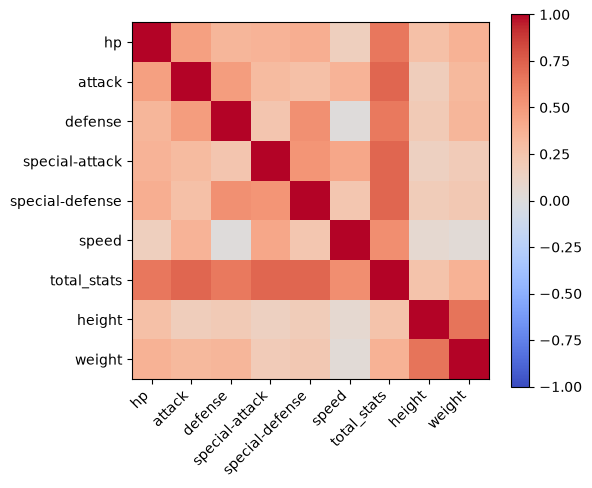

In [11]:
# Which stat correlates most with total_stats variance, and do height/weight track bulk?
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)), corr.columns)
fig.colorbar(im)
plt.tight_layout()


In [12]:
# Top 10 Pokemon by total_stats
pokemon.sort_values("total_stats", ascending=False)[["name", "category"] + stat_cols + ["total_stats"]].head(10)


,name,category,hp,attack,defense,special-attack,special-defense,speed,total_stats
1214,eternatus-eternamax,legendary,255,115,250,125,250,130,1125
1103,rayquaza-mega,legendary,105,180,100,180,100,115,780
1067,mewtwo-mega-x,legendary,106,190,100,154,100,130,780
1068,mewtwo-mega-y,legendary,106,150,70,194,120,140,780
1325,zygarde-mega,legendary,216,70,91,216,85,100,778
1102,groudon-primal,legendary,100,180,160,150,90,90,770
1101,kyogre-primal,legendary,100,150,90,180,160,90,770
1181,necrozma-ultra,legendary,97,167,97,167,97,129,754
492,arceus,mythical,120,120,120,120,120,120,720
1144,zygarde-complete,legendary,216,100,121,91,95,85,708


## 6. Type analysis

In [13]:
# How many types does each Pokemon have?
n_types = types.groupby("pokemon_id", observed=True).size()
n_types.value_counts().sort_index().to_frame("n_pokemon")


,n_pokemon
1,586
2,765


In [14]:
# Most common single types
types["type_name"].value_counts()


type_name
water       192
normal      160
grass       156
flying      154
psychic     142
dragon      117
electric    114
fire        109
fighting    109
poison      106
bug         106
rock        104
steel        99
dark         99
ground       96
ghost        96
fairy        88
ice          69
Name: count, dtype: int64

In [15]:
# Most common dual-type combos
dual = (
    types.groupby("pokemon_id", observed=True)["type_name"]
    .apply(lambda s: tuple(sorted(s)))
)
dual[dual.apply(len) == 2].value_counts().head(15)


type_name
(flying, normal)    31
(flying, rock)      18
(grass, poison)     17
(ghost, grass)      16
(bug, flying)       15
(bug, poison)       14
(rock, water)       12
(dragon, water)     12
(dragon, ground)    12
(fairy, psychic)    11
(fairy, steel)      11
(psychic, steel)    11
(flying, water)     10
(ground, water)     10
(dark, water)       10
Name: count, dtype: int64

In [16]:
# Average total_stats by type (a Pokemon with 2 types counts toward both)
type_stats = (
    types.merge(pokemon[["id", "total_stats"] + stat_cols], left_on="pokemon_id", right_on="id")
    .groupby("type_name", observed=True)
    .agg(n_pokemon=("pokemon_id", "nunique"), avg_total_stats=("total_stats", "mean"))
    .sort_values("avg_total_stats", ascending=False)
)
type_stats


,n_pokemon,avg_total_stats
type_name,,
dragon,117,558.846154
steel,99,505.171717
fighting,109,504.862385
psychic,142,492.570423
fire,109,476.522936
dark,99,475.858586
ice,69,473.840580
fairy,88,465.625000
flying,154,462.831169


## 7. Legendary / mythical / baby comparison

In [17]:
pokemon.groupby("category", observed=True).agg(
    n=("id", "count"),
    avg_total_stats=("total_stats", "mean"),
    avg_base_experience=("base_experience", "mean"),
    avg_hp=("hp", "mean"),
    avg_speed=("speed", "mean"),
).sort_values("avg_total_stats", ascending=False)


,n,avg_total_stats,avg_base_experience,avg_hp,avg_speed
category,,,,,
legendary,120,622.341667,283.974576,99.083333,100.125000
mythical,38,606.315789,272.264706,85.078947,98.973684
normal,1174,432.649915,147.635721,68.724872,68.747871
baby,19,274.473684,58.368421,53.947368,41.368421


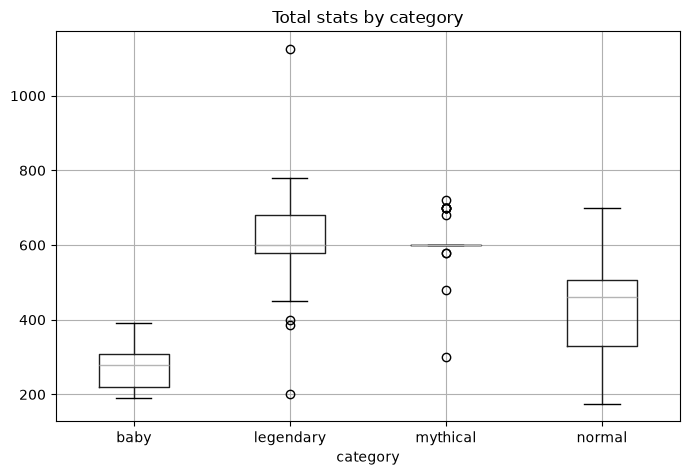

In [18]:
pokemon.boxplot(column="total_stats", by="category", figsize=(7, 5))
plt.suptitle("")
plt.title("Total stats by category")
plt.tight_layout()


## 8. Moves analysis

In [19]:
# How many moves can each Pokemon learn?
moves_per_pokemon = moves.groupby("pokemon_id", observed=True).size()
moves_per_pokemon.describe()


count    1303.000000
mean       76.369148
std        25.291442
min         1.000000
25%        61.000000
50%        76.000000
75%        91.000000
max       375.000000
dtype: float64

In [20]:
# Most "versatile" Pokemon (largest movepool)
top_movepool = (
    moves_per_pokemon.sort_values(ascending=False)
    .head(10)
    .to_frame("n_moves")
    .merge(pokemon[["id", "name"]], left_index=True, right_on="id")
    [["name", "n_moves"]]
)
top_movepool


,name,n_moves
150,mew,375
492,arceus,173
149,mewtwo,167
35,clefable,164
34,clefairy,161
39,wigglytuff,153
474,gallade,151
38,jigglypuff,148
112,chansey,144
148,dragonite,139


In [21]:
# Most common moves across all Pokemon
moves["move_name"].value_counts().head(15)


move_name
protect         1281
substitute      1277
rest            1275
sleep-talk      1274
facade          1264
endure          1241
snore           1112
round           1108
toxic            981
swagger          977
double-team      962
hidden-power     944
confide          944
return           942
frustration      942
Name: count, dtype: int64

In [22]:
# Does movepool size correlate with total_stats?
merged = moves_per_pokemon.to_frame("n_moves").merge(
    pokemon[["id", "total_stats"]], left_index=True, right_on="id"
)
merged[["n_moves", "total_stats"]].corr()


,n_moves,total_stats
n_moves,1.000000,0.248088
total_stats,0.248088,1.000000


## 9. Game-version availability

Note: "version" here means individual game releases (`red`, `blue`, `heartgold`, `sword`, ...),
not generations — several versions belong to the same generation (e.g. `red`/`blue`/`yellow`).


In [23]:
versions["version_name"].value_counts()


version_name
the-crown-tundra-sword      424
the-crown-tundra-shield     424
shield                      397
sword                       396
ultra-sun                   378
ultra-moon                  377
x                           358
y                           357
the-isle-of-armor-shield    299
the-isle-of-armor-sword     299
black-2                     294
white-2                     293
platinum                    290
heartgold                   284
soulsilver                  284
pearl                       278
diamond                     277
sun                         253
moon                        251
white                       240
black                       240
crystal                     170
emerald                     158
gold                        151
silver                      151
firered                     140
leafgreen                   140
omega-ruby                  132
alpha-sapphire              132
ruby                        129
sapphire                   

In [24]:
# How many versions does each Pokemon appear in?
versions_per_pokemon = versions.groupby("pokemon_id", observed=True).size()
versions_per_pokemon.describe()


count    927.000000
mean       9.771305
std        7.337256
min        1.000000
25%        4.000000
50%        8.000000
75%       13.000000
max       36.000000
dtype: float64

In [25]:
# Pokemon appearing in the fewest versions (version-exclusive or newest releases)
rare_pokemon = (
    versions_per_pokemon.sort_values()
    .head(10)
    .to_frame("n_versions")
    .merge(pokemon[["id", "name"]], left_index=True, right_on="id")
    [["name", "n_versions"]]
)
rare_pokemon


,name,n_versions
155,quilava,1
684,slurpuff,1
682,aromatisse,1
70,victreebel,1
158,croconaw,1
444,garchomp,1
152,bayleef,1
271,ludicolo,1
138,omastar,1
140,kabutops,1


## 10. Next steps

Ideas to extend this notebook:
- Type effectiveness matrix (requires a separate type-matchup table, not in the current dataset)
- Cluster Pokemon by stat profile (k-means on the six base stats) to find natural "archetypes"
- Move-type overlap: do Pokemon mostly learn moves matching their own type(s)?
- Generation-level trends (map versions to generations and compare average stats over time)
- Predict `base_experience` from base stats / category with a simple regression
